# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

## Opgave 1

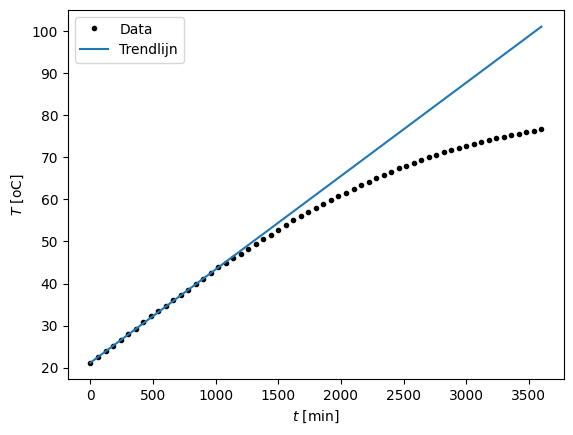

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = np.loadtxt("tempmetingen.csv",delimiter=';',skiprows=1)
tijd = data[:,0]*60 # in seconden
temp = data[:,1]

# Parameters
m_maatbeker = 820.8 #g
m_tot_start = 1292.9 #g
m_tot_eind = 1274.9 #g
m_water_start = (m_tot_start - m_maatbeker)*1e-3
m_water_eind = (m_tot_eind - m_maatbeker)*1e-3
delta_m = (m_tot_start - m_tot_eind)*1e-3
L = 2.26e6
c = 4180 #J/(kgK)

# Fit
start_temp = temp[0]

def fit(P, t):
    return start_temp + P/(m_water_start*c)*t

val, cov = curve_fit(fit, tijd[:20], temp[:20])

# PLot
plt.figure()
plt.plot(tijd, temp,'k.', label="Data")
plt.plot(tijd, fit(tijd, *val), label="Trendlijn")
plt.xlabel("$t$ [min]")
plt.ylabel("$T$ [oC]")
plt.legend()
plt.show()

## Opgave 2

In [ ]:
Q_verdampen = delta_m*L # energie verbruikt om water te verdampen (aanname: verschil in massa komt alleen door verdamping)
Q_verwarmen = c*m_water_start*(temp[-1] - temp[0]) # energie nodig voor opwarmen (aanname: geen water verdampt en alle energie wordt gestopt in het verwarmen van het water)
Q_tot = Q_verdampen + Q_verwarmen # (aanname: de warmte wordt alleen gestopt in het verwarmen en verdampen van water)
Q_geleverd = val[0]*60*60 # Q = P*t
print("De energie die de verwarming heeft geleverd is %.0f J en de energie die het water heeft opgenomen is %.0f J." %(Q_geleverd, Q_tot))
print("Dit komt goed met elkaar overeen.")

De energie die de verwarming heeft geleverd is 157552 J en de energie die het water heeft opgenomen is 150005 J.
Dit komt goed met elkaar overeen.


## Opgave 3

Ter verbetering van het onderzoek kan de maatbeker het beste geïsoleerd zijn om zo warmteverliezen naar de omgeving te beperken. Ook kan de maatbeker het beste constant geroerd met behulp van een magnetische roerder, zodat de temperatuur van het water homogeen is in het mengsel.